Construire un RNN de prévision

Il est temps de construire votre premier réseau récurrent ! Il s’agira d’un modèle séquence-vers-vecteur composé d’une couche RNN avec deux couches et un hidden_size de 32. Après la couche RNN, une simple couche linéaire projettera les sorties vers une valeur unique à prédire.

Les imports suivants ont déjà été effectués pour vous :


In [ ]:
import torch
import torch.nn as nn

In [ ]:
import torch.optim as optim

Définissez la couche RNN en lui passant les bonnes valeurs pour input_size, hidden_size, num_layers et batch_first, puis assignez-la à self.rnn.

Initialisez l’état caché initial h0 comme un tenseur de zéros avec la forme appropriée.

Faites passer l’entrée x et l’état caché initial h0 à travers la couche récurrente.

Faites passer la dernière sortie de la couche récurrente dans la couche linéaire

In [ ]:
class Net_RNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Define RNN layer
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
      # Initialize first hidden state with zeros
      h0 = torch.zeros(2, x.size(0), 32).to(DEVICE) # Move h0 to the correct device
      # Pass x and h0 through recurrent layer
      out, _ = self.rnn(x, h0)
      # Pass recurrent layer's last output through linear layer
      out = self.fc(out[:, -1, :])
      return out

Réseau LSTM

Comme vous le savez déjà, les cellules RNN simples sont rarement utilisées en pratique. Une alternative bien plus répandue, qui gère bien mieux les longues séquences, est la cellule Long Short-Term Memory, ou LSTM. Dans cet exercice, vous allez construire vous-même un réseau LSTM !

La différence d’implémentation la plus importante par rapport au réseau RNN que vous avez construit précédemment vient du fait que les LSTM possèdent deux états cachés au lieu d’un. Vous devrez donc initialiser cet état caché supplémentaire et le transmettre à la cellule LSTM.

Dans la méthode .__init__(), définissez une couche LSTM et assignez-la à self.lstm.
Dans la méthode forward(), initialisez le premier état caché de la mémoire à long terme c0 avec des zéros.
Dans la méthode forward(), passez les trois entrées à la couche LSTM : les entrées au pas de temps courant, et un tuple contenant les deux états caché

In [ ]:
class Net_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # Define lstm layer
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32).to(DEVICE) # Move h0 to the correct device
        # Initialize long-term memory
        c0 = torch.zeros(2, x.size(0), 32).to(DEVICE) # Move c0 to the correct device
        # Pass all inputs to lstm layer
        out, _ = self.lstm(x, (h0,c0))
        out = self.fc(out[:, -1, :])
        return out

Réseau GRU

À côté des LSTM, une autre variante populaire des réseaux de neurones récurrents est le Gated Recurrent Unit, ou GRU. Son intérêt réside dans sa simplicité : les cellules GRU nécessitent moins de calcul que les cellules LSTM tout en offrant souvent des performances comparables.

Le code fourni correspond à la définition du modèle RNN que vous avez écrit précédemment. Votre tâche est de l’adapter pour obtenir un réseau GRU à la place

In [ ]:
class Net_GRU(nn.Module):
    def __init__(self):
        super().__init__()
        # Define RNN layer
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32).to(DEVICE) # Move h0 to the correct device
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

Lien vers le dataset https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

In [ ]:
import pandas as pd

file_path = "/content/AEP_hourly.csv"

# Load data
df = pd.read_csv(
    file_path,
    sep=',',
    na_values='?',
    low_memory=False
)

In [ ]:
df

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
...,...,...
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0


In [ ]:
df = df.rename(columns={'Datetime': 'datetime'})
print(df.head())

              datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0


In [ ]:
#mt_columns = [col for col in df.columns if col.startswith('MT_036')]
#for col in mt_columns:
#    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
#    df[col] = pd.to_numeric(df[col], errors='coerce')
#df['MT_sum'] = df[mt_columns].sum(axis=1)
#print(df.head())

In [ ]:
df.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [ ]:
# rename "AEP_MW" to consumption
df.rename(columns={"AEP_MW":"Total_consumption"}, inplace=True)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   datetime           121273 non-null  datetime64[ns]
 1   Total_consumption  121273 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 MB
None


In [ ]:
start_year = df['datetime'].min().year
end_date = pd.to_datetime(f'{start_year + 0}-12-01')

df_two_years = df[df['datetime'] < end_date]

print("DataFrame for the first two years:")
print(df_two_years.head())
print("\nDataFrame Info for the first two years:")
print(df_two_years.info())

DataFrame for the first two years:
               datetime  Total_consumption
744 2004-11-30 01:00:00            14437.0
745 2004-11-30 02:00:00            14061.0
746 2004-11-30 03:00:00            13843.0
747 2004-11-30 04:00:00            13818.0
748 2004-11-30 05:00:00            14062.0

DataFrame Info for the first two years:
<class 'pandas.core.frame.DataFrame'>
Index: 1462 entries, 744 to 2206
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   datetime           1462 non-null   datetime64[ns]
 1   Total_consumption  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 34.3 KB
None


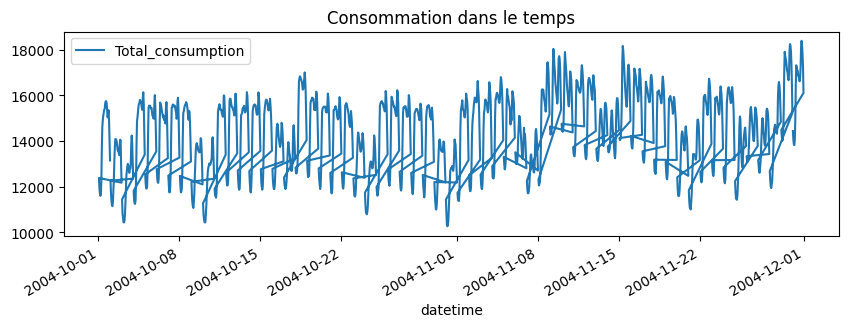

In [ ]:
df_two_years.plot(x="datetime", y="Total_consumption", figsize=(10,3), title="Consommation dans le temps")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()
#df['consumption_scaled'] = scaler.fit_transform(df[['Total_consumption']])

#print(df.head())

In [ ]:
df.isna().sum()

,0
datetime,0
Total_consumption,0


In [ ]:
df

,datetime,Total_consumption
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
...,...,...
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0


## 2. Découpage entraînement/test (chronologique) & standardisation

- On réserve **20%** des derniers points pour le test (`TEST_RATIO`).  
- On standardise la variable cible avec `StandardScaler` (*fit* sur **train** uniquement) pour stabiliser l’entraînement.

In [ ]:
TEST_RATIO = 0.2

df = df.sort_values("datetime").reset_index(drop=True)
n = len(df)
n_test = int(n * TEST_RATIO)
n_train = n - n_test

train_df = df.iloc[:n_train].copy()
test_df  = df.iloc[n_train:].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df["consumption_scaled"] = scaler.fit_transform(train_df[["Total_consumption"]])
test_df["consumption_scaled"]  = scaler.transform(test_df[["Total_consumption"]])

train_df.head(), test_df.head(), (len(train_df), len(test_df))

(             datetime  Total_consumption  consumption_scaled
 0 2004-10-01 01:00:00            12379.0           -1.280439
 1 2004-10-01 02:00:00            11935.0           -1.451864
 2 2004-10-01 03:00:00            11692.0           -1.545684
 3 2004-10-01 04:00:00            11597.0           -1.582363
 4 2004-10-01 05:00:00            11681.0           -1.549931,
                  datetime  Total_consumption  consumption_scaled
 97019 2015-10-27 11:00:00            14796.0           -0.347257
 97020 2015-10-27 12:00:00            14718.0           -0.377372
 97021 2015-10-27 13:00:00            14689.0           -0.388568
 97022 2015-10-27 14:00:00            14609.0           -0.419456
 97023 2015-10-27 15:00:00            14459.0           -0.477369,
 (97019, 24254))

In [ ]:
import numpy as np

def creer_sequences(serie: pd.Series, seq_length: int):
    xs, ys = [], []
    values = serie.values
    for i in range(len(values) - seq_length):
        x = values[i:i+seq_length]
        y = values[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LEN = 24  # 24h  (créneaux de 1h par jours)
X_train, y_train = creer_sequences(train_df["consumption_scaled"], SEQ_LEN)
X_test,  y_test  = creer_sequences(test_df["consumption_scaled"],  SEQ_LEN)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((96995, 24), (96995,), (24230, 24), (24230,))

In [ ]:
train_df.head(25)

,datetime,Total_consumption,consumption_scaled
0,2004-10-01 01:00:00,12379.0,-1.280439
1,2004-10-01 02:00:00,11935.0,-1.451864
2,2004-10-01 03:00:00,11692.0,-1.545684
3,2004-10-01 04:00:00,11597.0,-1.582363
4,2004-10-01 05:00:00,11681.0,-1.549931
5,2004-10-01 06:00:00,12280.0,-1.318662
6,2004-10-01 07:00:00,13692.0,-0.773501
7,2004-10-01 08:00:00,14618.0,-0.415981
8,2004-10-01 09:00:00,14903.0,-0.305945
9,2004-10-01 10:00:00,15118.0,-0.222935


In [ ]:
X_train[0]

array([-1.28043927, -1.45186381, -1.54568399, -1.58236266, -1.54993099,
       -1.31866231, -0.77350141, -0.41598088, -0.30594486, -0.22293523,
       -0.17505991, -0.12370977, -0.11251312, -0.01560421,  0.01682746,
        0.01682746, -0.01985121, -0.13220378, -0.2553669 , -0.18702874,
       -0.13374814, -0.33142689, -0.62871718, -0.98392116])

In [ ]:
y_train[0]

np.float64(-1.3263841380749015)

In [ ]:
X_train[1]

array([-1.45186381, -1.54568399, -1.58236266, -1.54993099, -1.31866231,
       -0.77350141, -0.41598088, -0.30594486, -0.22293523, -0.17505991,
       -0.12370977, -0.11251312, -0.01560421,  0.01682746,  0.01682746,
       -0.01985121, -0.13220378, -0.2553669 , -0.18702874, -0.13374814,
       -0.33142689, -0.62871718, -0.98392116, -1.32638414])

## 4. TensorDataset & DataLoader

Les couches récurrentes attendent des tenseurs de forme `(batch, seq_len, features)`. Ici on a **une** feature, donc on reshaping en `(B, SEQ_LEN, 1)` au moment de l’entraînement.【7†/mnt/data/chapter3.pdf】

In [ ]:
from torch.utils.data import TensorDataset, DataLoader


try:
    import torchmetrics
    from torchmetrics.regression import MeanSquaredError
except Exception as e:
    print("torchmetrics non installé ; on basculera sur un calcul MSE manuel.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu"))
DEVICE

torchmetrics non installé ; on basculera sur un calcul MSE manuel.


device(type='cuda')

In [ ]:
BATCH_SIZE = 64

train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
test_ds  = TensorDataset(torch.from_numpy(X_test).float(),  torch.from_numpy(y_test).float())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)  # ordre préservé
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(test_loader)

(1516, 379)

Boucle d'entraînement d'une RNN

Il est temps d’entraîner le modèle de prévision de la consommation d’électricité !

Vous allez utiliser le réseau LSTM que vous avez défini précédemment, déjà instancié et affecté à net, ainsi que le dataloader_train que vous avez construit plus tôt. Vous devrez également utiliser torch.nn, déjà importé sous le nom nn.

Dans cet exercice, vous entraînerez le modèle pendant seulement trois époques afin de vérifier que l’apprentissage progresse comme prévu. Allons-y !

In [ ]:
def entrainer_un_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for seqs, labels in loader:
        seqs = seqs.to(DEVICE).unsqueeze(-1)  # (B, T) -> (B, T, 1)
        labels = labels.to(DEVICE).unsqueeze(-1) # Reshape labels to (B, 1)
        optimizer.zero_grad()
        preds = model(seqs)  # (B, 1)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total += loss.item() * seqs.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluer(model, loader, criterion):
    model.eval()
    total = 0.0
    # torchmetrics si disponible
    mse_metric = None
    try:
        import torchmetrics
        from torchmetrics.regression import MeanSquaredError
        mse_metric = MeanSquaredError().to(DEVICE)
    except Exception:
        pass

    all_preds, all_labels = [], []
    for seqs, labels in loader:
        seqs = seqs.to(DEVICE).unsqueeze(-1)
        labels = labels.to(DEVICE).unsqueeze(-1) # Reshape labels to (B, 1)
        preds = model(seqs)
        loss = criterion(preds, labels)
        total += loss.item() * seqs.size(0)
        if mse_metric is not None:
            mse_metric.update(preds, labels)
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
    avg_loss = total / len(loader.dataset)
    if mse_metric is not None:
        metric_val = mse_metric.compute().item()
    else:
        import numpy as np
        y = torch.cat(all_labels).numpy()
        p = torch.cat(all_preds).numpy()
        metric_val = float(np.mean((p - y)**2))
    return avg_loss, metric_val

In [ ]:
EPOCHS = 20
LR = 1e-3

def executer_modele(model_cls, nom):
    model = model_cls().to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    losses = []

    for epoch in range(1, EPOCHS+1):
        tr = entrainer_un_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_mse = evaluer(model, test_loader, criterion)
        losses.append(tr)
        print(f"[{nom}] Époque {epoch:02d} | loss_train={tr:.4f} | loss_test={val_loss:.4f} | MSE_test={val_mse:.4f}")
    return model, losses

infos = {}

for cls, nm in [(Net_RNN, "RNN"), (Net_LSTM, "LSTM"), (Net_GRU, "GRU")]:

    m, l = executer_modele(cls, nm)
    infos[nm] = {"model": m, "losses": l}

[RNN] Époque 01 | loss_train=0.0347 | loss_test=0.0133 | MSE_test=0.0133
[RNN] Époque 02 | loss_train=0.0144 | loss_test=0.0125 | MSE_test=0.0125
[RNN] Époque 03 | loss_train=0.0118 | loss_test=0.0086 | MSE_test=0.0086
[RNN] Époque 04 | loss_train=0.0090 | loss_test=0.0079 | MSE_test=0.0079
[RNN] Époque 05 | loss_train=0.0080 | loss_test=0.0081 | MSE_test=0.0081
[RNN] Époque 06 | loss_train=0.0074 | loss_test=0.0085 | MSE_test=0.0085
[RNN] Époque 07 | loss_train=0.0069 | loss_test=0.0085 | MSE_test=0.0085
[RNN] Époque 08 | loss_train=0.0064 | loss_test=0.0076 | MSE_test=0.0076
[RNN] Époque 09 | loss_train=0.0062 | loss_test=0.0077 | MSE_test=0.0077
[RNN] Époque 10 | loss_train=0.0059 | loss_test=0.0082 | MSE_test=0.0082
[RNN] Époque 11 | loss_train=0.0056 | loss_test=0.0087 | MSE_test=0.0087
[RNN] Époque 12 | loss_train=0.0054 | loss_test=0.0086 | MSE_test=0.0086
[RNN] Époque 13 | loss_train=0.0053 | loss_test=0.0083 | MSE_test=0.0083
[RNN] Époque 14 | loss_train=0.0053 | loss_test=0.0

### 8. Courbes d’entraînement (loss)

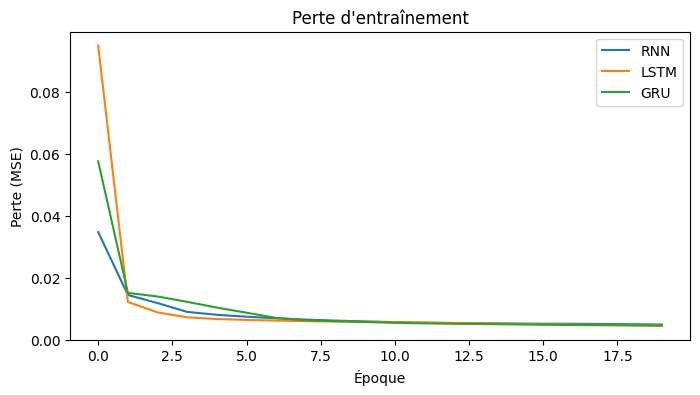

In [ ]:
plt.figure(figsize=(8,4))
for nm, info in infos.items():
    plt.plot(info["losses"], label=nm)
plt.xlabel("Époque")
plt.ylabel("Perte (MSE)")
plt.title("Perte d'entraînement")
plt.legend()
plt.show()